In [192]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns


---------------------Prework---------------------

In [193]:
df = pd.read_csv('heart.csv')


In [194]:
df.columns


Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [195]:
df[['Cholesterol', 'RestingBP']] = df[['Cholesterol', 'RestingBP']].replace(0,np.nan)


In [196]:
impute_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
imputer = KNNImputer(n_neighbors=5)
df[impute_cols] = imputer.fit_transform(df[impute_cols])


In [197]:
df['MaxHR_Ratio'] = df['MaxHR']/(220-df['Age'])

In [198]:
scaler = StandardScaler()
le = LabelEncoder()

In [199]:
df_normal = scaler.fit_transform(df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'MaxHR_Ratio']])

In [200]:
cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in cols:
    df[col] = le.fit_transform(df[col])

-------------------------------Model Building & Training-----------------------------

In [201]:
X_cat = df['ChestPainType']
X_num = df.drop(['HeartDisease', 'ChestPainType'], axis=1)
y = df['HeartDisease']
X_train_num, X_test_num, X_train_cat, X_test_cat, y_train, y_test = train_test_split(
    X_num, X_cat, y, test_size=0.2, random_state=42
)
y_probs = model.predict([X_test_num, X_test_cat])
y_pred_test = (y_probs > 0.5)



6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


In [202]:
input_num = Input(shape=(X_train_num.shape[1],), name='input_numeric')
input_cat = Input(shape=(1,), name='input_category')
embedding = Embedding(input_dim=4, output_dim=3, name='embedding_layer')(input_cat)
flatten = Flatten()(embedding)
merged = Concatenate()([input_num, flatten])


In [203]:
x = Dense(128, activation='relu')(merged)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(16, activation='relu')(x)


In [204]:
output = Dense(1, activation='sigmoid', name='output')(x)
model = Model(inputs=[input_num, input_cat], outputs=output)
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt,
              loss='binary_crossentropy',
              metrics=['accuracy', 'AUC'])

In [205]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_category      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_layer     │ (None, 1, 3)      │         12 │ input_category[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_numeric       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 3)         │          0 │ embedding_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 14)        │          0 │ input_numeric[0]… │
│ (Concatenate)       │                   │            │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_58 (Dense)    │ (None, 128)       │      1,920 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_58[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 64)        │      8,256 │ dropout_40[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_59[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_41          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_60 (Dense)    │ (None, 32)        │      2,080 │ dropout_41[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_42          │ (None, 32)        │          0 │ dense_60[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_61 (Dense)    │ (None, 64)        │      2,112 │ dropout_42[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_61[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_43          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_62 (Dense)    │ (None, 32)        │      2,080 │ dropout_43[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_62[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_44          │ (None, 32)        │          0 │ batch_normalizat

 Total params: 18,157 (70.93 KB)

 Trainable params: 17,581 (68.68 KB)

 Non-trainable params: 576 (2.25 KB)

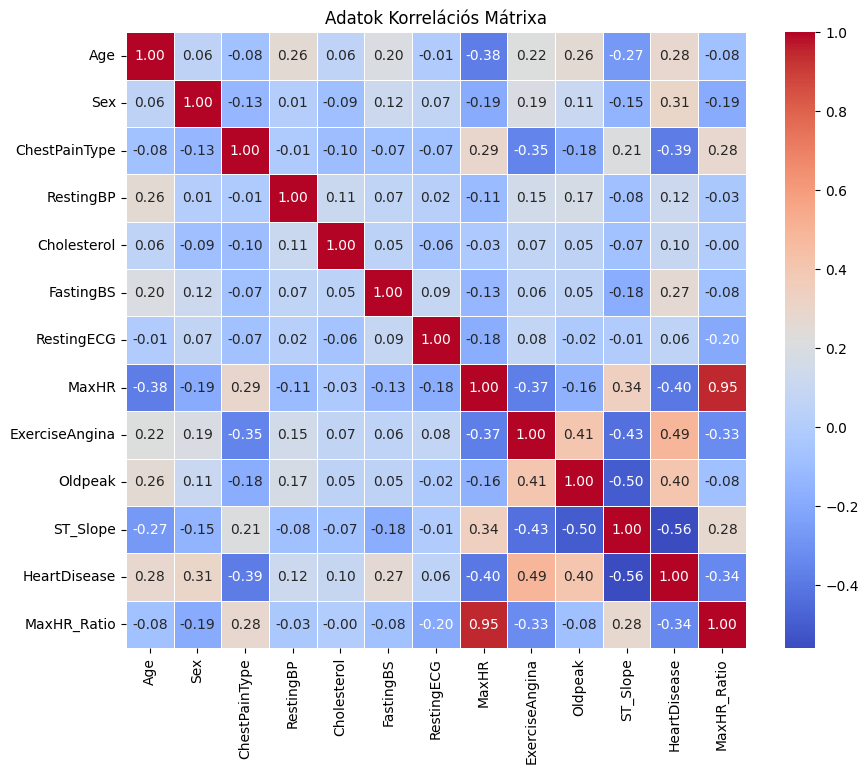

In [206]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Adatok Korrelációs Mátrixa')
plt.show()



In [207]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

In [208]:
history = model.fit(
    x=[X_train_num, X_train_cat],
    y=y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - AUC: 0.5422 - accuracy: 0.5230 - loss: 0.7985 - val_AUC: 0.4337 - val_accuracy: 0.4966 - val_loss: 0.7354
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - AUC: 0.5531 - accuracy: 0.5349 - loss: 0.7849 - val_AUC: 0.4742 - val_accuracy: 0.4830 - val_loss: 0.7131
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.6405 - accuracy: 0.6218 - loss: 0.6857 - val_AUC: 0.4763 - val_accuracy: 0.5170 - val_loss: 0.7211
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.6432 - accuracy: 0.6082 - loss: 0.6771 - val_AUC: 0.5729 - val_accuracy: 0.5442 - val_loss: 0.6954
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.6856 - accuracy: 0.6405 - loss: 0.6500 - val_AUC: 0.6723 - val_accuracy: 0.6259 - val_loss: 0.6671
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.7236 - accuracy: 0.6797 - loss: 0.6250 - val_AUC: 0.7304 - val_accuracy: 0.6259 - val_loss: 0.6369
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0

In [209]:
test_loss, test_auc, test_accuracy = model.evaluate([X_test_num, X_test_cat], y_test)
print(f"Teszt Loss: {test_loss}")
print(f"Teszt Accuracy: {test_accuracy}")
print(f"Teszt AUC: {test_auc}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - AUC: 0.8950 - accuracy: 0.7989 - loss: 0.4531 
Teszt Loss: 0.45309457182884216
Teszt Accuracy: 0.8950115442276001
Teszt AUC: 0.7989130616188049


------------------------------------Vizualization------------------------------------

In [210]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']


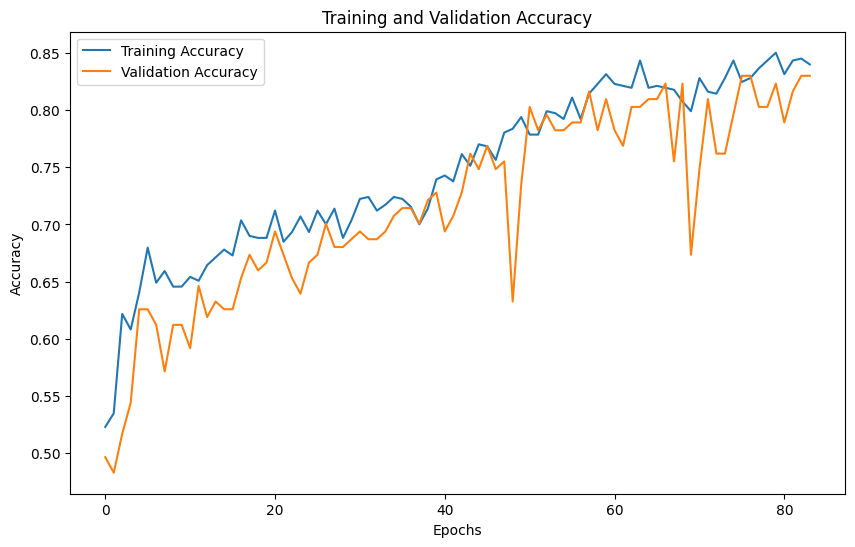

In [211]:
plt.figure(figsize=(10, 6))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


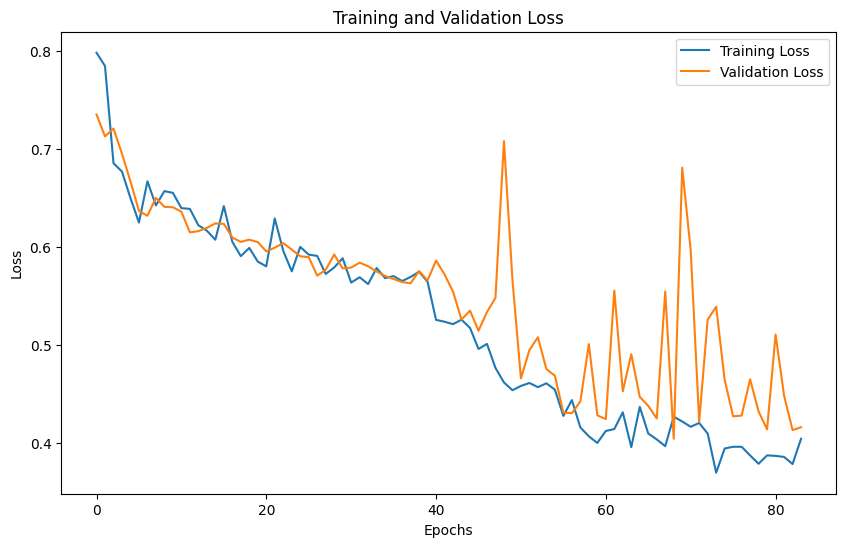

In [212]:
plt.figure(figsize=(10, 6))
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

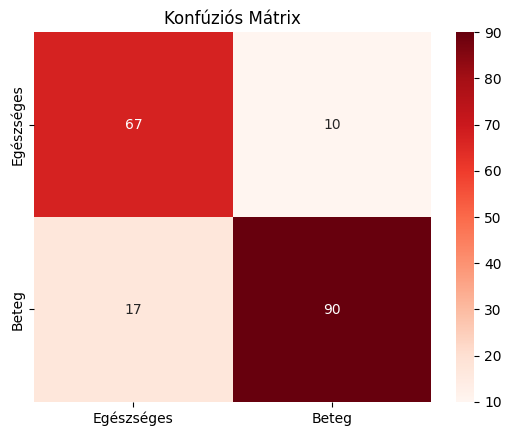

In [213]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds',
            xticklabels=['Egészséges', 'Beteg'],
            yticklabels=['Egészséges', 'Beteg'])
plt.title('Konfúziós Mátrix')
plt.grid(False) 
plt.show()


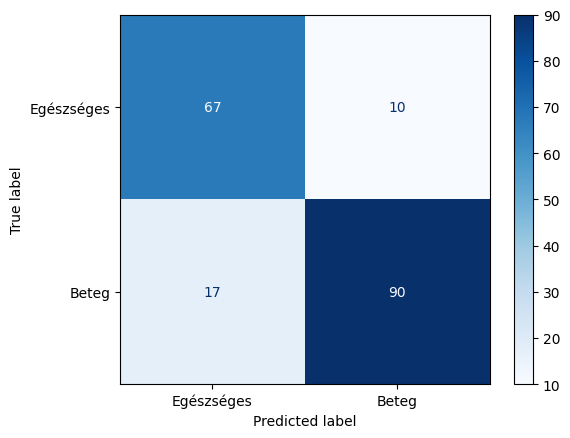

In [214]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, 
                                        display_labels=['Egészséges', 'Beteg'], 
                                        cmap='Blues')